In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO(r"D:\wildlife-monitoring\best_models\medium-50.pt")

In [ ]:
model.val(data='data.yaml', split='test')

In [ ]:
# Configure matplotlib for inline display
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

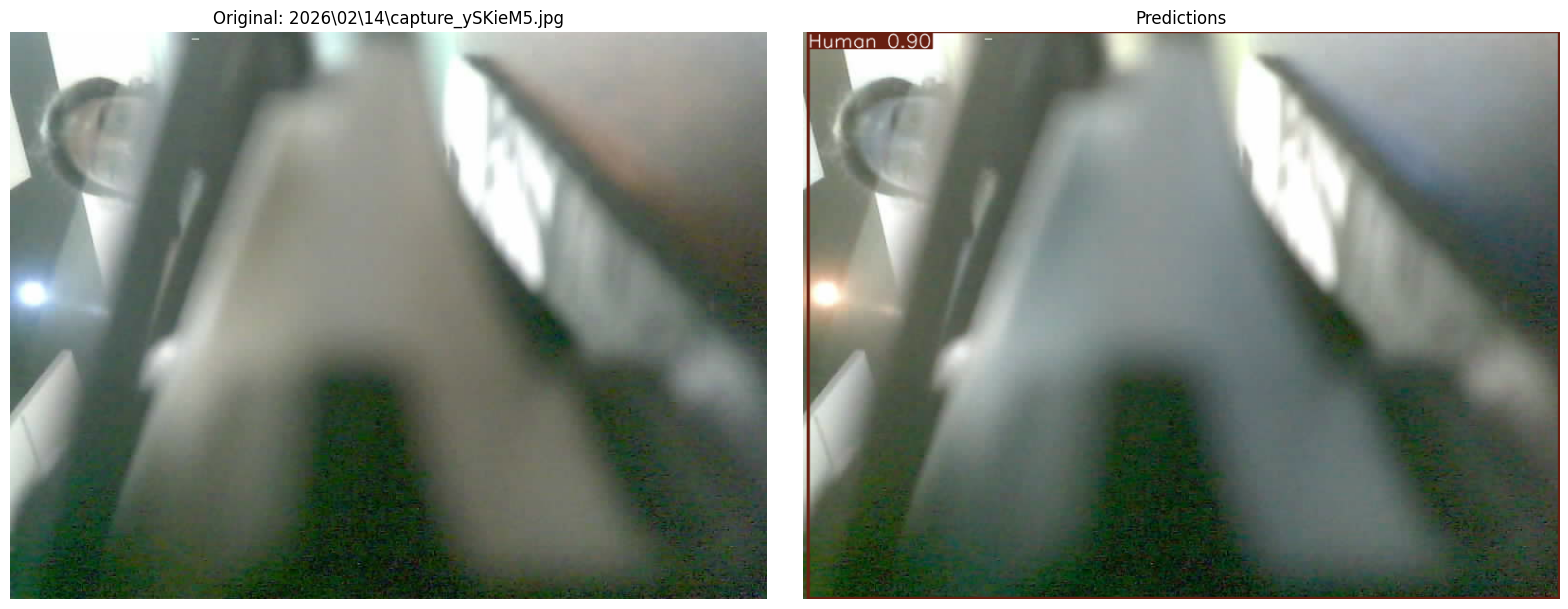

  Detected: Human (Confidence: 89.88%)
--------------------------------------------------

Predicting for: 2026\02\14\capture_zBVuaCE.jpg

image 1/1 D:\wildlife-monitoring\dashboard\server\media\captured_images\2026\02\14\capture_zBVuaCE.jpg: 288x384 1 Bison, 1 Human, 62.7ms
Speed: 3.0ms preprocess, 62.7ms inference, 2.3ms postprocess per image at shape (1, 3, 288, 384)


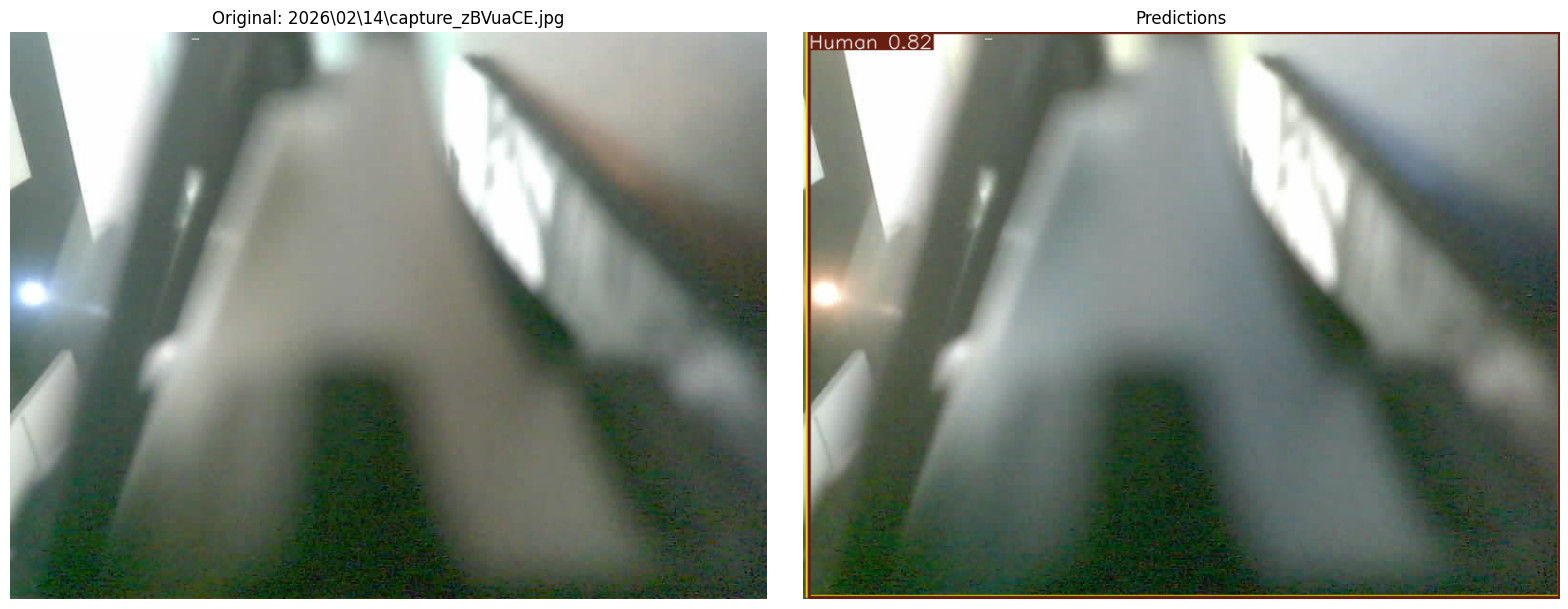

  Detected: Human (Confidence: 82.27%)
  Detected: Bison (Confidence: 36.94%)
--------------------------------------------------

Predicting for: 2026\02\14\capture_zf0iK1v.jpg

image 1/1 D:\wildlife-monitoring\dashboard\server\media\captured_images\2026\02\14\capture_zf0iK1v.jpg: 288x384 1 Human, 96.6ms
Speed: 3.6ms preprocess, 96.6ms inference, 3.4ms postprocess per image at shape (1, 3, 288, 384)


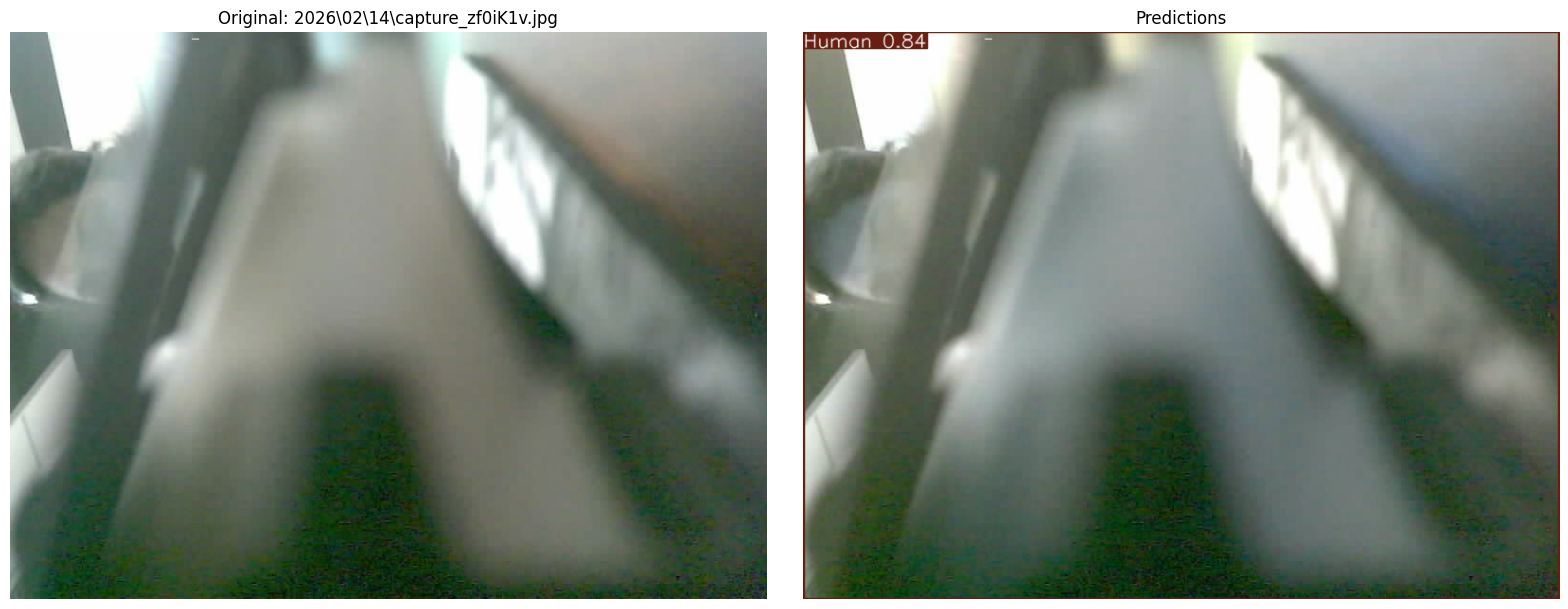

  Detected: Human (Confidence: 84.48%)
--------------------------------------------------

Predicting for: 2026\02\14\thetrio1.jpg

image 1/1 D:\wildlife-monitoring\dashboard\server\media\captured_images\2026\02\14\thetrio1.jpg: 256x384 1 Bear, 1 Tiger, 93.3ms
Speed: 3.3ms preprocess, 93.3ms inference, 5.0ms postprocess per image at shape (1, 3, 256, 384)


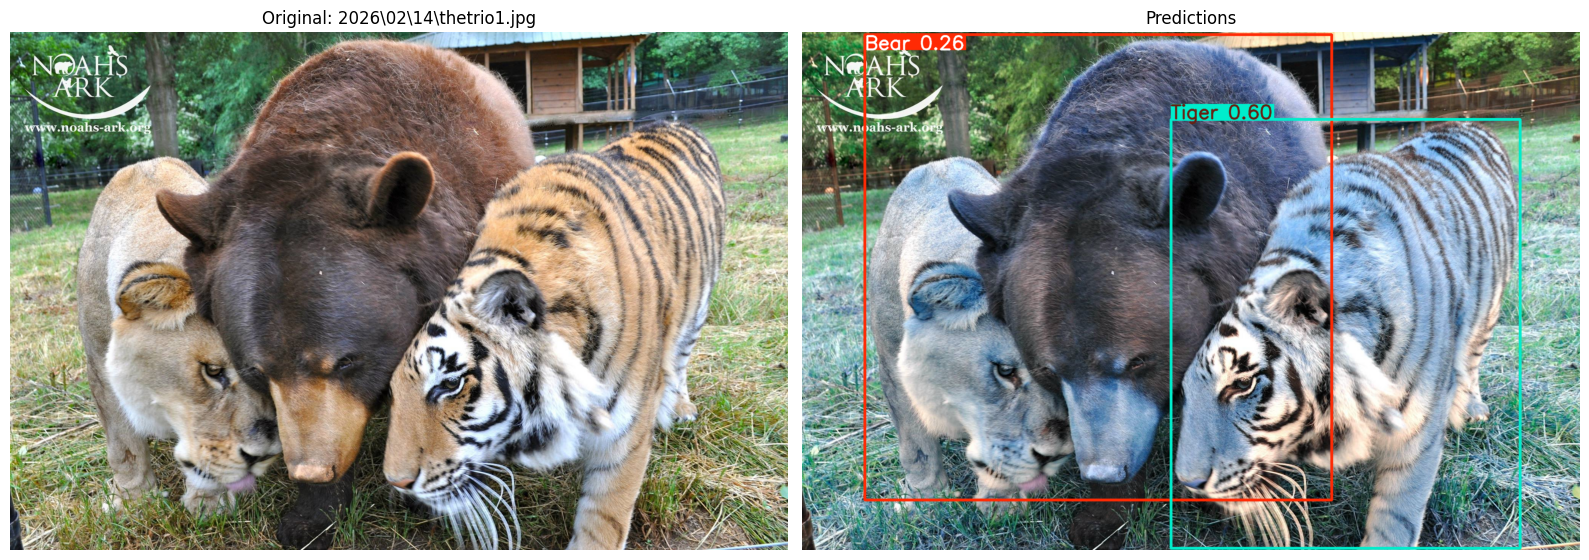

  Detected: Tiger (Confidence: 60.38%)
  Detected: Bear (Confidence: 26.41%)
--------------------------------------------------


In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Path to media folder
media_folder = r"D:\wildlife-monitoring\dashboard\server\media\captured_images"

# Get all image files recursively
image_files = []
for root, dirs, files in os.walk(media_folder):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} images in media folder\n")

# Process each image
for image_path in image_files:
    # Get relative path for display
    rel_path = os.path.relpath(image_path, media_folder)
    
    # Load image
    img = Image.open(image_path).convert("RGB")
    
    # Run prediction once
    print(f"\nPredicting for: {rel_path}")
    results = model(image_path)
    annotated_img = results[0].plot()
    
    # Side-by-side display: original vs annotated
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Original: {rel_path}", fontsize=12)
    
    axes[1].imshow(annotated_img)
    axes[1].axis("off")
    axes[1].set_title("Predictions", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print detections
    for result in results:
        boxes = result.boxes
        if len(boxes) == 0:
            print("  No detections.")
        for box in boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = result.names[class_id]
            print(f"  Detected: {class_name} (Confidence: {confidence:.2%})")
    
    print("-" * 50)

In [6]:
import cv2
from IPython.display import display, clear_output
import numpy as np

# Path to test folder
test_folder = "test/videos"

# Get all video files
video_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]

print(f"Found {len(video_files)} videos in test folder\n")

# Process each video
for video_file in video_files:
    video_path = os.path.join(test_folder, video_file)
    
    print(f"\nProcessing video: {video_file}")
    print("-" * 50)
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"FPS: {fps}, Total Frames: {total_frames}")
    
    frame_count = 0
    display_every = max(1, fps // 2)  # Display every half second
    
    while cap.isOpened():
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frame_count += 1
        
        # Process every Nth frame to avoid overwhelming output
        if frame_count % display_every == 0:
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Make prediction
            results = model(frame)
            
            # Get annotated frame
            annotated_frame = results[0].plot()
            
            # Display side by side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            # Original frame
            axes[0].imshow(frame_rgb)
            axes[0].axis('off')
            axes[0].set_title(f'Original Frame {frame_count}/{total_frames}', fontsize=12)
            
            # Annotated frame
            axes[1].imshow(annotated_frame)
            axes[1].axis('off')
            axes[1].set_title(f'Predictions', fontsize=12)
            
            plt.tight_layout()
            plt.show()
            
            # Print detections
            for result in results:
                boxes = result.boxes
                if len(boxes) > 0:
                    print(f"Frame {frame_count} detections:")
                    for box in boxes:
                        class_id = int(box.cls[0])
                        confidence = float(box.conf[0])
                        class_name = result.names[class_id]
                        print(f"  {class_name} ({confidence:.2%})")
    
    cap.release()
    print(f"\nFinished processing: {video_file}")
    print("=" * 50)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'test/videos'